In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/global_green_energy_pulse_20260112.csv")

In [ ]:
print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu:")
print(df.head())

Kích thước dữ liệu: (1920, 7)

5 dòng đầu:
       city                 time  shortwave_radiation  wind_speed_100m  \
0  New York  2026-01-05 00:00:00                  0.0             22.9   
1  New York  2026-01-05 01:00:00                  0.0             23.4   
2  New York  2026-01-05 02:00:00                  0.0             28.2   
3  New York  2026-01-05 03:00:00                  0.0             30.0   
4  New York  2026-01-05 04:00:00                  0.0             29.7   

   green_score  latitude  longitude  
0     0.763333     40.71      -74.0  
1     0.780000     40.71      -74.0  
2     0.940000     40.71      -74.0  
3     1.000000     40.71      -74.0  
4     0.990000     40.71      -74.0  


In [ ]:
print("\nThông tin dataset:")
print(df.info())

print("\nSố giá trị thiếu:")
print(df.isnull().sum())


Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 1920 non-null   object 
 1   time                 1920 non-null   object 
 2   shortwave_radiation  1920 non-null   float64
 3   wind_speed_100m      1920 non-null   float64
 4   green_score          1920 non-null   float64
 5   latitude             1920 non-null   float64
 6   longitude            1920 non-null   float64
dtypes: float64(5), object(2)
memory usage: 105.1+ KB
None

Số giá trị thiếu:
city                   0
time                   0
shortwave_radiation    0
wind_speed_100m        0
green_score            0
latitude               0
longitude              0
dtype: int64


In [ ]:
df_clean = df.dropna()

print("Số dòng sau khi làm sạch:", df_clean.shape[0])

Số dòng sau khi làm sạch: 1920


In [ ]:
print("==============================")
print("HỒI QUY: BỨC XẠ → GREEN SCORE")
print("==============================")

model1 = smf.ols(
    formula="green_score ~ shortwave_radiation",
    data=df_clean
).fit()

print(model1.summary())


# Phương trình
intercept = model1.params['Intercept']
slope = model1.params['shortwave_radiation']

print("\nPhương trình hồi quy:")
print(f"green_score = {intercept:.4f} + {slope:.6f} * shortwave_radiation")

HỒI QUY: BỨC XẠ → GREEN SCORE
                            OLS Regression Results                            
Dep. Variable:            green_score   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     500.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.14e-98
Time:                        14:16:36   Log-Likelihood:                -1101.8
No. Observations:                1920   AIC:                             2208.
Df Residuals:                    1918   BIC:                             2219.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Inte

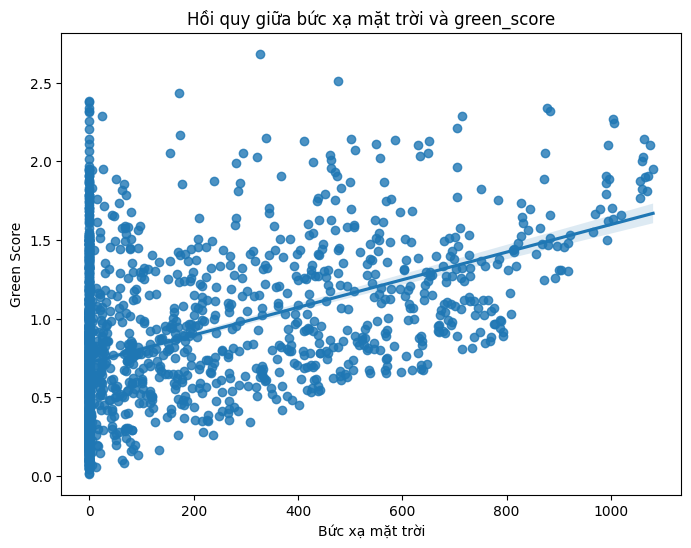

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="shortwave_radiation",
    y="green_score",
    data=df_clean
)

plt.title("Hồi quy giữa bức xạ mặt trời và green_score")
plt.xlabel("Bức xạ mặt trời")
plt.ylabel("Green Score")

plt.show()

In [ ]:
print("--- Tạo biến phân loại wind ---")

df_clean['wind_level'] = pd.cut(
    df_clean['wind_speed_100m'],
    bins=3,
    labels=["Low", "Medium", "High"]
)

print(df_clean['wind_level'].value_counts())


print("==============================")
print("HỒI QUY: WIND LEVEL → GREEN SCORE")
print("==============================")

model2 = smf.ols(
    formula="green_score ~ C(wind_level)",
    data=df_clean
).fit()

print(model2.summary())

--- Tạo biến phân loại wind ---
wind_level
Low       1253
Medium     592
High        75
Name: count, dtype: int64
HỒI QUY: WIND LEVEL → GREEN SCORE
                            OLS Regression Results                            
Dep. Variable:            green_score   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     1232.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:34   Log-Likelihood:                -530.88
No. Observations:                1920   AIC:                             1068.
Df Residuals:                    1917   BIC:                             1084.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      

In [ ]:
means = df_clean.groupby("wind_level", observed=True)["green_score"].mean()

print("--- Giá trị trung bình dự đoán ---")
print(means)

--- Giá trị trung bình dự đoán ---
wind_level
Low       0.605262
Medium    1.239860
High      1.921925
Name: green_score, dtype: float64


/tmp/ipykernel_16410/46430128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


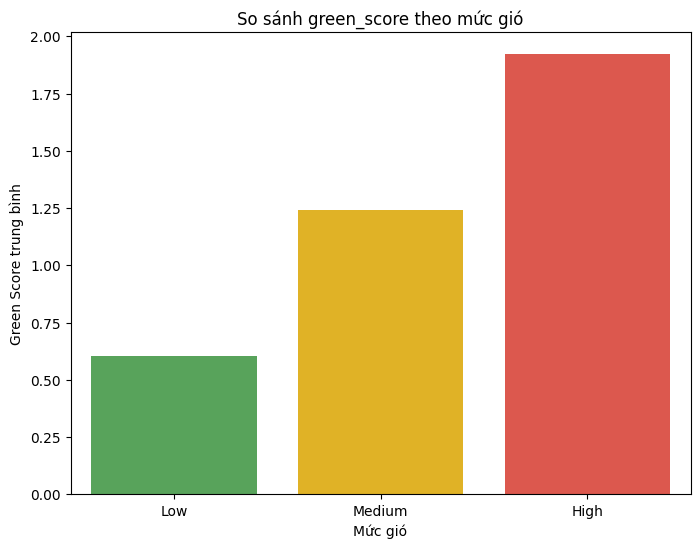

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="wind_level",
    y="green_score",
    data=df_clean,
    errorbar=None,
    palette=["#4CAF50", "#FFC107", "#F44336"]
)

plt.title("So sánh green_score theo mức gió")
plt.xlabel("Mức gió")
plt.ylabel("Green Score trung bình")

plt.show()